# Final Project - Snow Cover - Notebook - Connor Oman

## Importing:

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np

drive.mount('/content/drive')
df_original = pd.read_csv('/content/drive/My Drive/wa_snow_temp_daily.csv')
df = df_original.copy()
print(df.info())
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11191401 entries, 0 to 11191400
Data columns (total 4 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   ID          object
 1   DATE        object
 2   ELEMENT     object
 3   DATA_VALUE  int64 
dtypes: int64(1), object(3)
memory usage: 341.5+ MB
None
            ID        DATE ELEMENT  DATA_VALUE
0  USW00024157  1985-01-01    TMAX         -78
1  USW00024157  1985-01-01    TMIN        -144
2  USW00024157  1985-01-01    SNOW           0
3  USW00024157  1985-01-01    SNWD         406
4  USW00024160  1985-01-01    TMAX         -61


## Cleaning & Reformatting the Data:

In [ ]:
# Converting to datetime instead of object
df['DATE'] = pd.to_datetime(df['DATE'],errors='coerce')
df['DATE'].min(), df['DATE'].max()

# Changing ID & Element to categorical to save memory
df['ID'] = df['ID'].astype('category')
df['ELEMENT'] = df['ELEMENT'].astype('category')

# Changing DATA_VALUE to numeric for future analysis
df['DATA_VALUE'] = pd.to_numeric(df['DATA_VALUE'],downcast='integer')

In [ ]:
# Adding a year and month column for future analysis
df['YEAR'] = df['DATE'].dt.year
df['MONTH'] = df['DATE'].dt.month

# An additional metric that indicates the winter
df['WINTER'] = df['MONTH'].isin([12,1,2])

# Converting TMAX and TMIN to actually be degrees Celsius instead of tenths of a degree
df.loc[df['ELEMENT'].isin(['TMAX', 'TMIN']), 'DATA_VALUE'] /= 10

/tmp/ipython-input-2142271504.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ -7.8 -14.4  -6.1 ...   8.3   9.4   1.1]' has dtype incompatible with int16, please explicitly cast to a compatible dtype first.
  df.loc[df['ELEMENT'].isin(['TMAX', 'TMIN']), 'DATA_VALUE'] /= 10


In [ ]:
df.groupby('ELEMENT',observed=True)['DATA_VALUE'].describe()

,count,mean,std,min,25%,50%,75%,max
ELEMENT,,,,,,,,
SNOW,2687969.0,2.469786,86.742864,0.0,0.0,0.0,0.0,25397.0
SNWD,2372689.0,192.727702,585.574848,-356.0,0.0,0.0,0.0,7366.0
TMAX,3067167.0,13.817896,10.220840,-99.0,6.4,13.3,21.1,3143.3
TMIN,3063576.0,3.466944,7.018071,-99.0,-1.1,3.3,8.4,371.1


The purpose of my project is to learn about the frequency of extreme weather events, so I shouldn't just remove outliers past a specific threshold.

However, the data isn't clean and contains some physically impossible values, therefore, I used NOAA as a reference to figure out the thresholds that are physically impossible for Washington state.

In [ ]:
print("Rows before the cleaning:", len(df))

# Defining possible measurements for Washington state.
valid_snow = (df['ELEMENT'] == 'SNOW')&df['DATA_VALUE'].between(0, 2000)
valid_snwd = (df['ELEMENT'] == 'SNWD')&df['DATA_VALUE'].between(0, 10000)
valid_tmax = (df['ELEMENT'] == 'TMAX')&df['DATA_VALUE'].between(-60, 60)
valid_tmin = (df['ELEMENT'] == 'TMIN')&df['DATA_VALUE'].between(-60, 40)

df = df[valid_tmax|valid_tmin|valid_snow|valid_snwd]
print("Rows after the cleaning:", len(df))

Rows before the cleaning: 11191401
Rows after the cleaning: 11190886


In [ ]:
# Checking missingness
df.groupby('ELEMENT', observed=True)[df.columns].apply(lambda x: x.isna().mean())

,ID,DATE,ELEMENT,DATA_VALUE,YEAR,MONTH,WINTER
ELEMENT,,,,,,,
SNOW,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SNWD,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TMAX,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TMIN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


We have literally no missing values which is a good sign.

/tmp/ipython-input-2885245791.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  coll_df = (df.pivot_table(index=['ID', 'DATE'],columns='ELEMENT',values='DATA_VALUE',aggfunc='mean'))


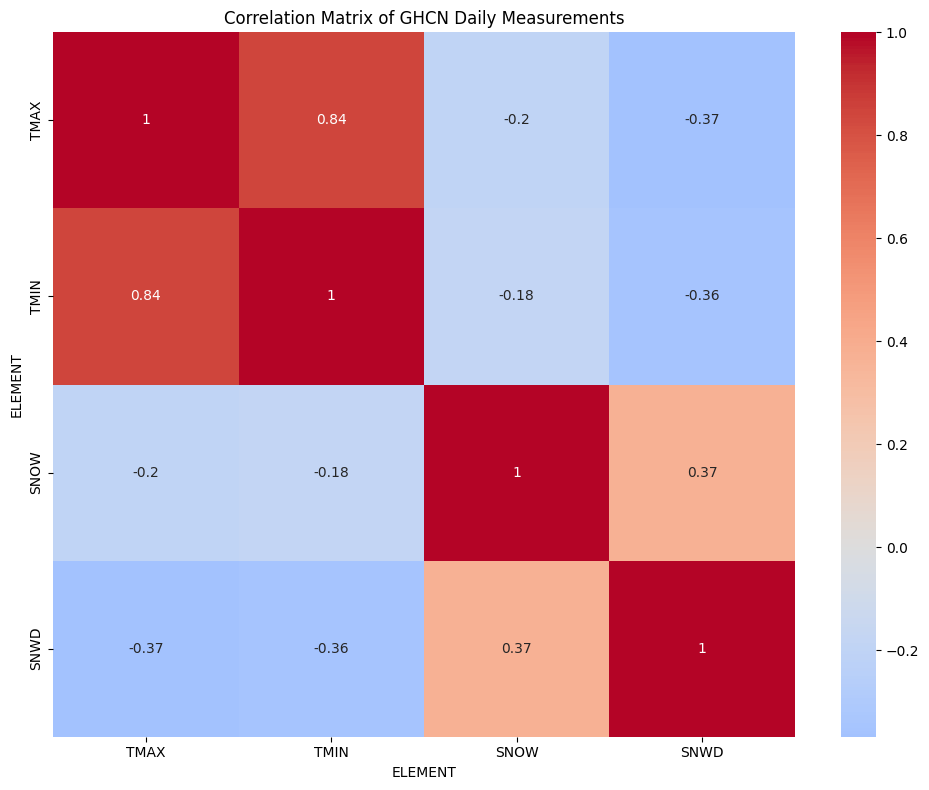

ELEMENT                 SNOW  SNWD  TMAX  TMIN
ID          DATE                              
US1WAAD0002 2009-04-29   0.0   NaN   NaN   NaN
            2009-04-30   0.0   NaN   NaN   NaN
            2009-05-01   0.0   NaN   NaN   NaN
            2009-05-02   0.0   NaN   NaN   NaN
            2009-05-03   0.0   NaN   NaN   NaN


In [ ]:
# Collinearity check
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot DATA_VALUE so each ELEMENT becomes its own column
coll_df = (df.pivot_table(index=['ID', 'DATE'],columns='ELEMENT',values='DATA_VALUE',aggfunc='mean'))

# Compute correlation matrix on the four measurements
c_matrix = coll_df[['TMAX', 'TMIN', 'SNOW', 'SNWD']].corr()

# Plot correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(c_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of GHCN Daily Measurements')
plt.tight_layout()
plt.show()

# Quick sanity check
print(coll_df.head())


## Aggregation & Regression:
Calculating the frequency of extreme snow events and how they've changed over time.

In [ ]:
# Aggregating the yearly & winter average temperatue for all stations
temper_df = df[df['ELEMENT'].isin(['TMAX', 'TMIN'])].copy()
annual_temper = temper_df.groupby(['ID','YEAR', 'ELEMENT'],observed=True)['DATA_VALUE'].mean().unstack('ELEMENT').reset_index()

winter_temper_df = df[(df['WINTER'] == True) & (df['ELEMENT'].isin(['TMAX','TMIN']))]
winter_temper = winter_temper_df.groupby(['ID', 'YEAR', 'ELEMENT'],observed=True)['DATA_VALUE'].mean().unstack('ELEMENT').reset_index()

# Aggregating the yearly & winter average snow for all stations
snow_df = df[df['ELEMENT'] == 'SNOW']
annual_snow = snow_df.groupby(['ID', 'YEAR'],observed=True)['DATA_VALUE'].sum().reset_index(name='SNOW_TOTAL')

winter_snow_df = df[(df['WINTER'] == True) & (df['ELEMENT'] == 'SNOW')]
winter_snow = winter_snow_df.groupby(['ID', 'YEAR'],observed=True)['DATA_VALUE'].sum().reset_index(name='WINTER_SNOW_TOTAL')

# Combining all the tables together
yearly_stats = annual_temper.merge(annual_snow, on=['ID', 'YEAR'], how='left').merge(winter_temper, on=['ID','YEAR'], how='left', suffixes=('', '_WINTER')).merge(winter_snow, on=['ID', 'YEAR'], how='left')

print(yearly_stats.head())

            ID  YEAR       TMAX      TMIN  SNOW_TOTAL  TMAX_WINTER  \
0  USC00450008  1985  13.866027  5.081918        21.0     7.391111   
1  USC00450008  1986  14.707671  7.063562         0.0     9.316667   
2  USC00450008  1987  14.860597  6.643881         0.0     9.241111   
3  USC00450008  1988  14.733333  6.836612         0.0     9.121978   
4  USC00450008  1989  14.646575  6.732329         0.0     7.905556   

   TMIN_WINTER  WINTER_SNOW_TOTAL  
0     0.060000               21.0  
1     3.087778                0.0  
2     2.355556                0.0  
3     2.769231                0.0  
4     1.781111                0.0  


Normal Snow Events:

In [ ]:
# Looking for normal snow days across every month from 1985 to 2025
# Must fall below the 90% percentile
winter_snow = df[(df['ELEMENT'] == 'SNOW') & (df['MONTH'].isin([12,1,2]))].copy()
extreme_snow = winter_snow['DATA_VALUE'].quantile(0.90)

snow_df = df[df['ELEMENT'] == 'SNOW'].copy()
snow_df.loc[:, 'Snow_Day'] = (snow_df['DATA_VALUE'] > 0) & (snow_df['DATA_VALUE'] <= extreme_snow)

# Counting the non-extreme snow days
yearly_snow_days = snow_df.groupby(['ID','YEAR'], observed=True)['Snow_Day'].sum().reset_index(name='Snow_Days')

stations = snow_df.groupby(['ID','YEAR'], observed=True)['DATA_VALUE'].count().reset_index(name='Total_Count')
yearly_snow = yearly_snow_days.merge(stations, on=['ID','YEAR'])

yearly_snow['Snow_Day_Rate'] = yearly_snow['Snow_Days'] / yearly_snow['Total_Count']

print(yearly_snow.head(88))


             ID  YEAR  Snow_Days  Total_Count  Snow_Day_Rate
0   US1WAAD0002  2009          0          127           0.00
1   US1WAAD0002  2010          0            9           0.00
2   US1WAAD0003  2009          0          124           0.00
3   US1WAAD0003  2010          0            8           0.00
4   US1WAAD0003  2011          0            8           0.00
..          ...   ...        ...          ...            ...
83  US1WAAS0005  2023          1            4           0.25
84  US1WAAS0005  2024          0            3           0.00
85  US1WAAS0005  2025          1            4           0.25
86  US1WABT0001  2008          0            1           0.00
87  US1WABT0001  2009          0            5           0.00

[88 rows x 5 columns]


Each station counts the normal snow days vs the total snow days for every year between 1985 & 2025.

                            OLS Regression Results                            
Dep. Variable:          Snow_Day_Rate   R-squared:                       0.459
Model:                            OLS   Adj. R-squared:                  0.445
Method:                 Least Squares   F-statistic:                     33.03
Date:                Mon, 15 Dec 2025   Prob (F-statistic):           1.16e-06
Time:                        00:30:50   Log-Likelihood:                 139.23
No. Observations:                  41   AIC:                            -274.5
Df Residuals:                      39   BIC:                            -271.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2495      0.220     -5.679      0.0

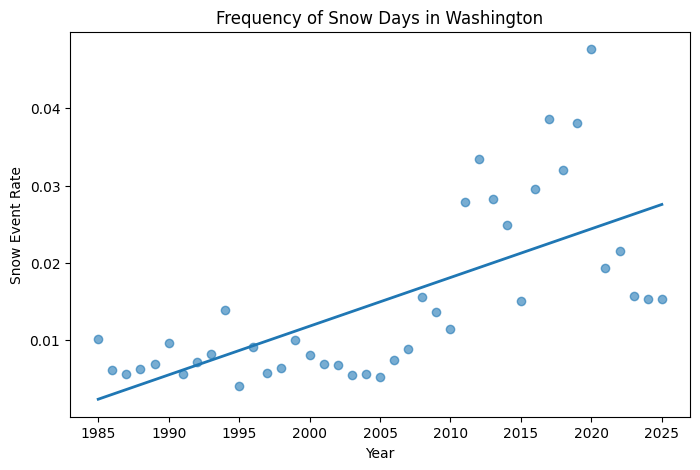

In [ ]:
# Checking yearly extremes with regression
statewide_yearly = yearly_snow.groupby('YEAR')['Snow_Day_Rate'].mean().reset_index()

# Regression
import statsmodels.api as sm

X = statewide_yearly['YEAR']
y = statewide_yearly['Snow_Day_Rate']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

plt.figure(figsize=(8,5))
plt.scatter(statewide_yearly['YEAR'], statewide_yearly['Snow_Day_Rate'], alpha=0.6)
plt.plot(statewide_yearly['YEAR'], model.predict(X), linewidth=2)
plt.xlabel("Year")
plt.ylabel("Snow Event Rate")
plt.title("Frequency of Snow Days in Washington")
plt.show()

The coef of YEAR is positive which indicates that normal snow events have become slightly more frequent.

This coef represents an average 0.06% increase in extreme snow events each year. If we multiply by 40 for the 40 year time span, we get 2.4%.

2.4% might not seem like a lot, but it is very significant in terms of climatology.

Random noise is ruled out as the P-value is very low.

### Extreme Snow Events Only:

In [ ]:
# Defining extreme snow as anything past the 90% percentile in the Winter
winter_snow = df[(df['ELEMENT'] == 'SNOW') & (df['MONTH'].isin([12,1,2]))].copy()
extreme_snow = winter_snow['DATA_VALUE'].quantile(0.90)

# Making a new Dataframe for when ELEMENT = Snow
snow_df = df[df['ELEMENT'] == 'SNOW'].copy()
snow_df.loc[:, 'Extreme_Snow_Days'] = snow_df['DATA_VALUE'] >= extreme_snow

# Counting the extreme snow days
yearly_extremes = snow_df.groupby(['ID','YEAR'], observed=True)['Extreme_Snow_Days'].sum().reset_index()

stations = snow_df.groupby(['ID','YEAR'], observed=True)['DATA_VALUE'].count().reset_index(name='Total_Snow_Days')
yearly_extremes = yearly_extremes.merge(stations, on=['ID','YEAR'])
yearly_extremes['Extreme_Event_Rate'] = yearly_extremes['Extreme_Snow_Days'] / yearly_extremes['Total_Snow_Days']

print(yearly_extremes.head(88))

             ID  YEAR  Extreme_Snow_Days  Total_Snow_Days  Extreme_Event_Rate
0   US1WAAD0002  2009                  0              127            0.000000
1   US1WAAD0002  2010                  0                9            0.000000
2   US1WAAD0003  2009                  0              124            0.000000
3   US1WAAD0003  2010                  3                8            0.375000
4   US1WAAD0003  2011                  0                8            0.000000
..          ...   ...                ...              ...                 ...
83  US1WAAS0005  2023                  2                4            0.500000
84  US1WAAS0005  2024                  1                3            0.333333
85  US1WAAS0005  2025                  2                4            0.500000
86  US1WABT0001  2008                  0                1            0.000000
87  US1WABT0001  2009                  0                5            0.000000

[88 rows x 5 columns]


Each station counts the extreme snow days vs the total snow days for every year between 1985 & 2025.

                            OLS Regression Results                            
Dep. Variable:     Extreme_Event_Rate   R-squared:                       0.360
Model:                            OLS   Adj. R-squared:                  0.344
Method:                 Least Squares   F-statistic:                     21.96
Date:                Mon, 15 Dec 2025   Prob (F-statistic):           3.36e-05
Time:                        00:30:51   Log-Likelihood:                 92.893
No. Observations:                  41   AIC:                            -181.8
Df Residuals:                      39   BIC:                            -178.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.1445      0.681     -4.616      0.0

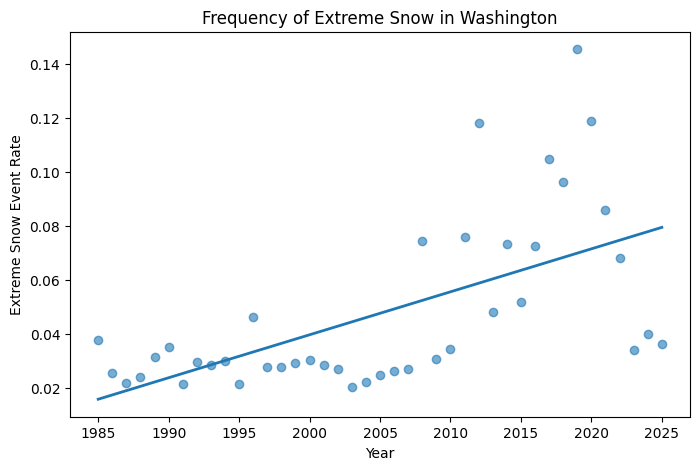

In [ ]:
# Checking yearly extremes with regression
statewide_yearly = yearly_extremes.groupby('YEAR')['Extreme_Event_Rate'].mean().reset_index()

# Regression
import statsmodels.api as sm

X = statewide_yearly['YEAR']
y = statewide_yearly['Extreme_Event_Rate']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

plt.figure(figsize=(8,5))
plt.scatter(statewide_yearly['YEAR'], statewide_yearly['Extreme_Event_Rate'], alpha=0.6)
plt.plot(statewide_yearly['YEAR'], model.predict(X), linewidth=2)
plt.xlabel("Year")
plt.ylabel("Extreme Snow Event Rate")
plt.title("Frequency of Extreme Snow in Washington")
plt.show()

The coef of YEAR is positive which indicates that extreme snow events have become slightly more frequent.

This coef represents an average 0.16% increase in extreme snow events each year. If we multiply by 40 for the 40 year time span, we get 6.4%.

6.4% might not seem like a lot, but it is very significant in terms of climatology.

Random noise is ruled out as the P-value is very low.

## Geospatial Analysis:
Mapping how extreme weather events change over time geospatially

*(a topic not covered in class)*

In [ ]:
# Installing geospatial data
!pip install geopandas shapely pyproj fiona
import geopandas as gpd

# Retrieving stations data (including latitude and longitude) from NOAA
stations_geo = pd.read_fwf("/content/drive/My Drive/ghcnd-stations.txt",widths=[11,9,10,7,3,31,4,4,6],names=["ID","LAT","LON","ELEV","STATE","NAME","GSN","HCN","WMO"])
stations_geo = stations_geo[stations_geo["STATE"] =="WA"]
print(stations_geo.head)

<bound method NDFrame.head of                  ID      LAT       LON   ELEV STATE                  NAME  \
98669   US1WAAD0002  46.7849 -119.1915  303.3    WA       OTHELLO 2.7 SSW   
98670   US1WAAD0003  46.8111 -119.1549  332.5    WA        OTHELLO 0.9 SE   
98671   US1WAAD0004  46.7838 -119.1912  302.1    WA       OTHELLO 2.8 SSW   
98672   US1WAAD0005  46.8321 -119.1562  341.4    WA       OTHELLO 1.0 NNE   
98673   US1WAAD0006  46.7611 -119.2181  259.7    WA       OTHELLO 4.8 SSW   
...             ...      ...       ...    ...   ...                   ...   
128735  USW00094274  47.2675 -122.5761   88.4    WA     TACOMA NARROWS AP   
128736  USW00094276  48.5200 -123.0264   34.1    WA      FRIDAY HARBOR AP   
128739  USW00094290  47.6872 -122.2553   18.3    WA   SEATTLE SAND PT WFO   
128740  USW00094297  48.2167 -122.6333   60.7    WA       COUPEVILLE NOLF   
128741  USW00094298  45.6211 -122.6542    6.4    WA  VANCOUVER PEARSON AP   

        GSN  HCN  WMO  
98669   NaN  NaN  NaN

In [ ]:
# Combining the geospatial stations with the yearly_extremes dataset made previously
stations_geo = stations_geo[stations_geo["STATE"] == "WA"]
geo_df = yearly_extremes.merge(stations_geo[["ID","LAT","LON"]],on="ID",how="left")
print(geo_df.head)

<bound method NDFrame.head of                 ID  YEAR  Extreme_Snow_Days  Total_Snow_Days  \
0      US1WAAD0002  2009                  0              127   
1      US1WAAD0002  2010                  0                9   
2      US1WAAD0003  2009                  0              124   
3      US1WAAD0003  2010                  3                8   
4      US1WAAD0003  2011                  0                8   
...            ...   ...                ...              ...   
12868  USW00094298  2014                  0              236   
12869  USW00094298  2015                  0              238   
12870  USW00094298  2016                  0              255   
12871  USW00094298  2017                  0              195   
12872  USW00094298  2018                  0              141   

       Extreme_Event_Rate      LAT       LON  
0                   0.000  46.7849 -119.1915  
1                   0.000  46.7849 -119.1915  
2                   0.000  46.8111 -119.1549  
3            

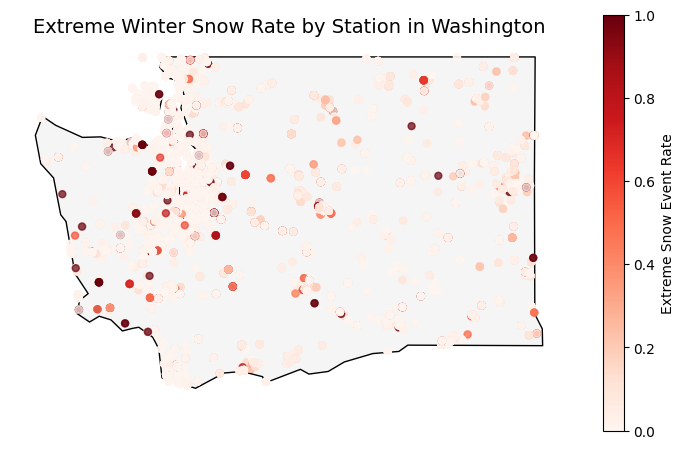

In [ ]:
# Plotting Washington state as the background.

# Loading the shapefile
states = gpd.read_file("https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json")
# Filtering for Washington
wa = states[states["name"] == "Washington"]

# Convert station data to GeoDataFrame
geo_gdf = gpd.GeoDataFrame(geo_df.dropna(subset=["LAT","LON"]),geometry=gpd.points_from_xy(geo_df["LON"], geo_df["LAT"]),crs="EPSG:4326")

# Creating the plot & background
fig, ax = plt.subplots(figsize=(9,9))
wa.plot(ax=ax, color="whitesmoke", edgecolor="black")

geo_gdf.plot(ax=ax,column="Extreme_Event_Rate",cmap="Reds",legend=True,
    legend_kwds={"label": "Extreme Snow Event Rate", "shrink": 0.6},
    markersize=25,
    alpha=0.7
)
ax.set_title("Extreme Winter Snow Rate by Station in Washington", fontsize=14)
ax.set_axis_off()
plt.show()


Darker reds mean that station has expierenced more extreme snow events compared to other stations.

Overall, a general trend can be seen where more extreme snow events are occuring in the West and less in the East.

## Other Relevant Figures:

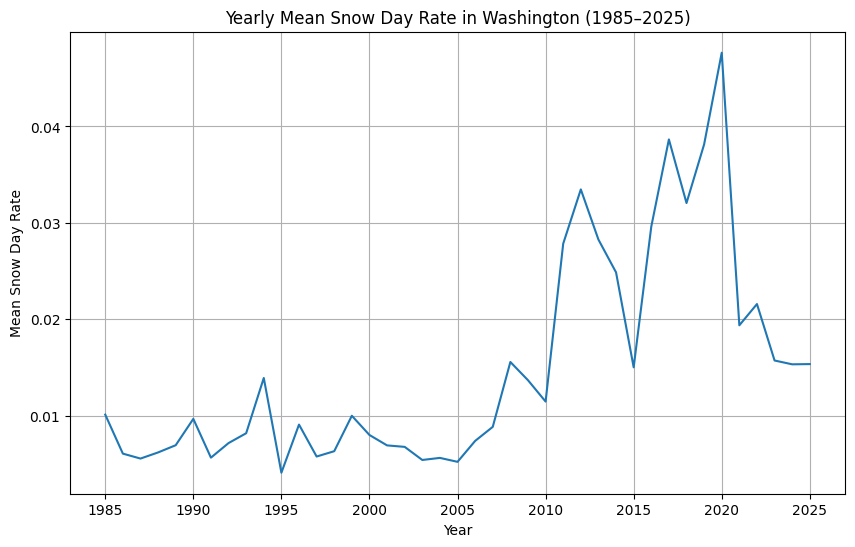

In [ ]:
# Timeseries of the mean snow day rate grouped by year
import matplotlib.pyplot as plt

statewide_trend = yearly_snow.groupby('YEAR', observed=True)['Snow_Day_Rate'].mean().reset_index()

plt.figure(figsize=(10,6))
plt.plot(statewide_trend['YEAR'], statewide_trend['Snow_Day_Rate'])
plt.xlabel('Year')
plt.ylabel('Mean Snow Day Rate')
plt.title('Yearly Mean Snow Day Rate in Washington (1985–2025)')
plt.grid(True)
plt.show()

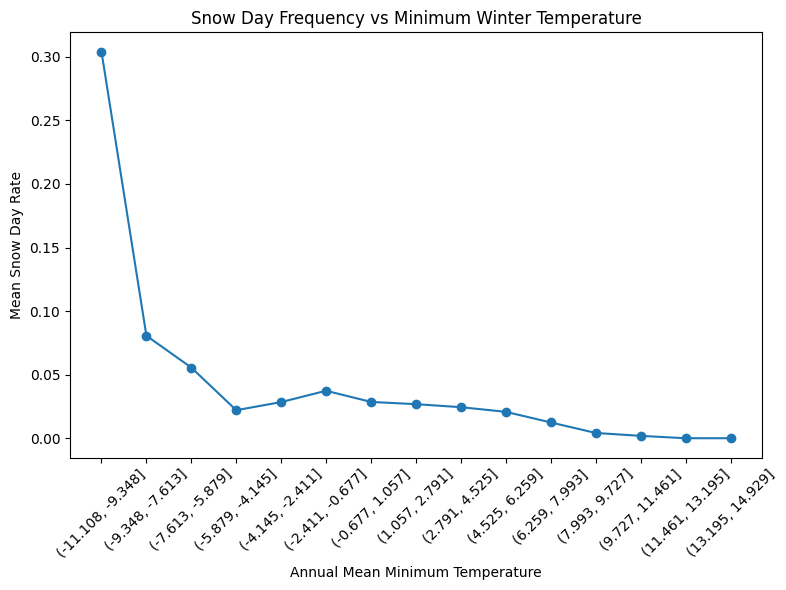

In [ ]:
# Minimum winter temperature vs Snow Day Rate
min_yearly = (df[df['ELEMENT'] == 'TMIN'].groupby(['ID','YEAR'], observed=True)['DATA_VALUE']
    .mean()
    .reset_index(name='TMIN')
)

df_binned = yearly_snow.merge(min_yearly, on=['ID','YEAR'], how='left')

df_binned['TMIN_bin'] = pd.cut(df_binned['TMIN'], bins=15)
binned = df_binned.groupby('TMIN_bin', observed=True)['Snow_Day_Rate'].mean().reset_index()

plt.figure(figsize=(8,6))
plt.plot(binned['TMIN_bin'].astype(str), binned['Snow_Day_Rate'], marker='o')
plt.xticks(rotation=45)
plt.xlabel('Annual Mean Minimum Temperature')
plt.ylabel('Mean Snow Day Rate')
plt.title('Snow Day Frequency vs Minimum Winter Temperature')
plt.tight_layout()
plt.show()


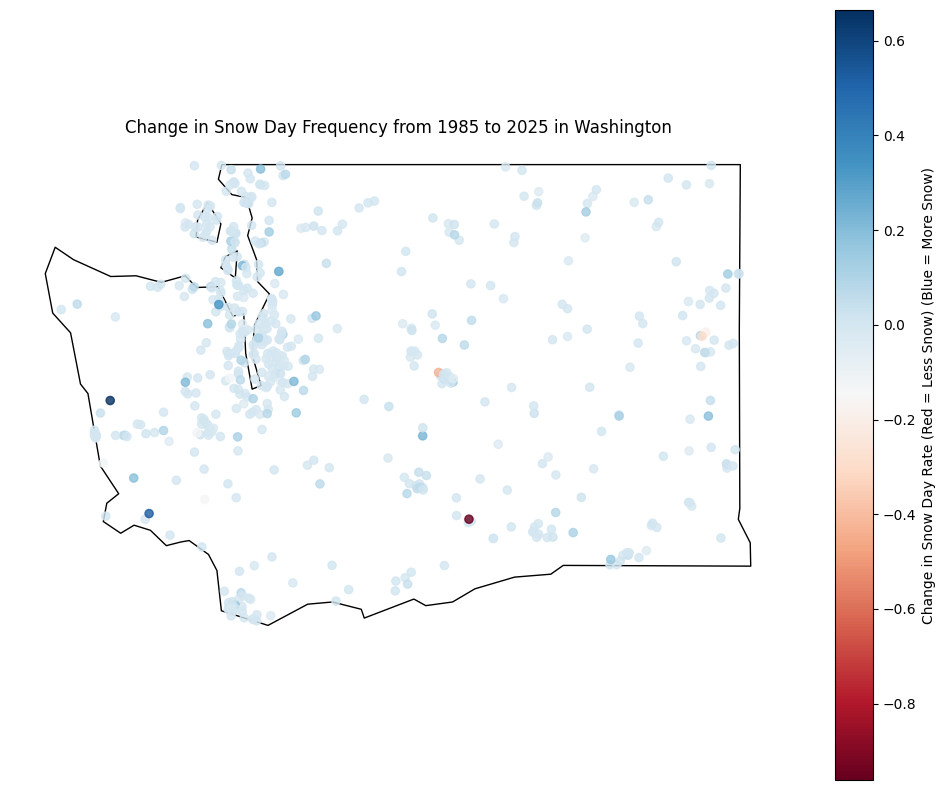

In [ ]:
# Plotting the difference between the former and latter half of the time span.

# Defining the former and latter
mid_year = yearly_snow['YEAR'].median()
yearly_snow['Period'] = np.where(yearly_snow['YEAR'] <= mid_year, 'former_half', 'latter_half')

period_avg = yearly_snow.groupby(['ID','Period'], observed=True)['Snow_Day_Rate'].mean().reset_index()
period_wide = period_avg.pivot(index='ID', columns='Period', values='Snow_Day_Rate').dropna()
period_wide['Rate_Change'] = period_wide['latter_half'] - period_wide['former_half']
period_wide = period_wide.reset_index()


# Station data
stations_geo = pd.read_fwf('/content/drive/My Drive/ghcnd-stations.txt',widths=[11,9,10,7,3,31,4,4,6],names=['ID','LAT','LON','ELEV','STATE','NAME','GSN','HCN','WMO'])
stations_geo = stations_geo[stations_geo['STATE'] == 'WA']

# Merge
geo_df = period_wide.merge(stations_geo[['ID','LAT','LON']], on='ID',how='left').dropna()
gdf = gpd.GeoDataFrame(geo_df,geometry=gpd.points_from_xy(geo_df['LON'],geo_df['LAT']),crs='EPSG:4326')

# Defining the Washington state geography
wa_map = gpd.read_file("https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json")
wa_map = wa_map[wa_map['name'] == 'Washington']


fig, ax = plt.subplots(1, 1, figsize=(10,8))
wa_map.plot(ax=ax, color='white', edgecolor='black')

gdf.plot(ax=ax,column='Rate_Change',cmap='RdBu',legend=True,
    legend_kwds={'label': 'Change in Snow Day Rate (Red = Less Snow) (Blue = More Snow)'},
    markersize=35,
    alpha=0.8
)
plt.title('Change in Snow Day Frequency from 1985 to 2025 in Washington')
plt.axis('off')
plt.tight_layout()
plt.show()